# Mundial 2026 — Simulación Monte Carlo

Estimamos **en cuántos escenarios sale campeona cada selección** simulando miles de veces
el resto del Mundial 2026, partiendo de:

1. el **ELO** de cada selección, y
2. las **tablas de posiciones actuales** de los 12 grupos (snapshot del torneo en curso).

Este notebook explica la lógica del ELO, la lógica de la simulación (modelo de partido,
fase de grupos y grilla de eliminatorias), corre **1.000.000 de escenarios** y grafica los
resultados.

> El **motor** (`wcsim.py`) usa solo la biblioteca estándar de Python. Acá agregamos
> `pandas`/`matplotlib` únicamente para la presentación y los gráficos.

## 1. Datos de entrada

| archivo | contenido |
|---------|-----------|
| `data/elo.csv`      | ELO de las 48 selecciones (escala clásica) |
| `data/groups.csv`   | snapshot de los 12 grupos: jugados, puntos, GF, GA |
| `data/fixtures.csv` | partidos de grupo que **faltan** jugar |
| `data/bracket.json` | plantilla oficial de la Ronda de 32 y la llave hasta la final |

In [1]:
import time
import math
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

import wcsim

plt.rcParams.update({"figure.dpi": 110, "font.size": 11, "axes.grid": True,
                     "grid.alpha": 0.3, "axes.axisbelow": True})

data = wcsim.load_all()
elo, groups, fixtures, bracket = data["elo"], data["groups"], data["fixtures"], data["bracket"]
print(f"{len(elo)} selecciones | {len(groups)} grupos | "
      f"{len(fixtures)} partidos de grupo por jugar | "
      f"{len(bracket['r32'])} cruces en la Ronda de 32")

pd.DataFrame(sorted(elo.items(), key=lambda x: -x[1]), columns=["Selección", "ELO"]).head(10)

48 selecciones | 12 grupos | 40 partidos de grupo por jugar | 16 cruces en la Ronda de 32


,Selección,ELO
0,Argentina,1889.06
1,France,1887.11
2,Spain,1856.03
3,England,1847.68
4,Brazil,1772.01
5,Morocco,1769.98
6,Netherlands,1764.40
7,Portugal,1755.09
8,Germany,1743.54
9,Belgium,1733.93


## 2. La lógica del ELO

El **ELO** es un número que resume la fuerza de cada selección a partir de su historial
de resultados (ganar a un rival fuerte suma más que ganar a uno débil). Lo importante para
la simulación no es el valor absoluto sino la **diferencia** entre dos equipos.

Dada la diferencia $\Delta = R_A - R_B$, el ELO predice la **probabilidad esperada** de que
$A$ le gane a $B$ (puntaje esperado, contando el empate como medio punto):

$$E_A = \frac{1}{1 + 10^{-\Delta/400}}$$

La constante **400** fija la escala: una ventaja de 400 puntos de ELO equivale a una
probabilidad esperada de $E_A = \tfrac{1}{1+10^{-1}} \approx 0.91$.

Las **sedes** (USA, México, Canadá) reciben un bonus de localía sumado a su ELO efectivo
($+60$ por defecto) que se aplica en cada partido que juegan.

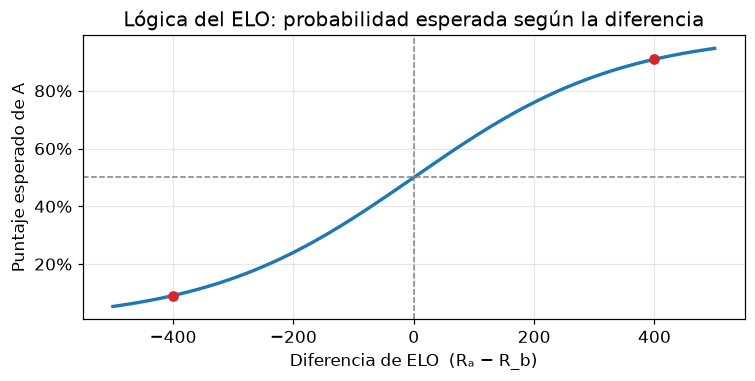

In [2]:
# Curva del ELO: probabilidad esperada en funcion de la diferencia de ELO
deltas = list(range(-500, 501, 5))
ev = [1 / (1 + 10 ** (-d / 400)) for d in deltas]

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(deltas, ev, lw=2.2, color="#1f77b4")
ax.axhline(0.5, color="grey", ls="--", lw=1)
ax.axvline(0, color="grey", ls="--", lw=1)
for d in (-400, 400):
    ax.scatter([d], [1 / (1 + 10 ** (-d / 400))], color="#d62728", zorder=5)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_xlabel("Diferencia de ELO  (Rₐ − R_b)")
ax.set_ylabel("Puntaje esperado de A")
ax.set_title("Lógica del ELO: probabilidad esperada según la diferencia")
plt.tight_layout(); plt.savefig("charts/01_curva_elo.png", bbox_inches="tight"); plt.show()

## 3. Del ELO a un resultado de partido: modelo Poisson

El ELO da una *probabilidad esperada*, pero para simular necesitamos un **marcador**
(hacen falta los goles para los desempates de grupo: diferencia de gol y goles a favor).

Modelamos los goles de cada equipo como dos variables **Poisson** independientes, cuyas
medias (goles esperados) salen de la diferencia de ELO:

$$\lambda_A = \text{base}\cdot 10^{\,\Delta/800}, \qquad
  \lambda_B = \text{base}\cdot 10^{-\Delta/800}$$

$$\text{goles}_A \sim \text{Poisson}(\lambda_A), \qquad
  \text{goles}_B \sim \text{Poisson}(\lambda_B)$$

El exponente **/800** hace que el cociente de goles esperados sea
$\lambda_A/\lambda_B = 10^{\Delta/400}$ — exactamente la forma del ELO clásico — mientras el
total de goles se mantiene aproximadamente constante. El parámetro `base` ($=1.35$) es el
nivel de goles esperados entre dos equipos parejos. El **empate** surge naturalmente cuando
ambos Poisson dan el mismo número.

En **eliminación directa**, si el partido termina empatado se define por penales con
probabilidad $E_A$ (derivada del ELO).

,Partido,λ local,λ visita,Gana,Empata,Pierde
0,Argentina vs Brazil,1.89,0.96,59%,22%,19%
1,Spain vs England,1.38,1.32,39%,26%,36%
2,France vs USA,1.89,0.96,59%,22%,19%
3,Mexico vs Germany,1.51,1.21,44%,25%,30%
4,Morocco vs Croatia,1.67,1.09,51%,24%,25%


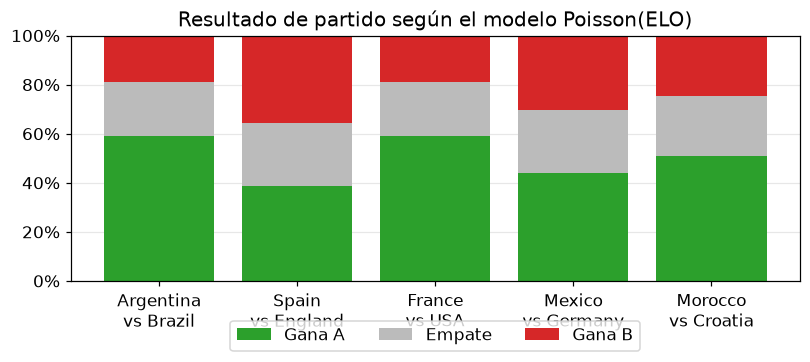

In [3]:
# A partir de las lambdas, las probabilidades G/E/P de un partido salen analiticamente
def pois_pmf(k, lam):
    return math.exp(-lam) * lam ** k / math.factorial(k)

def wdl(a, b, model, maxg=12):
    la, lb = model.lambdas(a, b)
    pa = [pois_pmf(k, la) for k in range(maxg)]
    pb = [pois_pmf(k, lb) for k in range(maxg)]
    win = draw = loss = 0.0
    for i in range(maxg):
        for j in range(maxg):
            p = pa[i] * pb[j]
            if i > j: win += p
            elif i == j: draw += p
            else: loss += p
    return win, draw, loss

model = wcsim.MatchModel(elo)
ejemplos = [("Argentina", "Brazil"), ("Spain", "England"),
            ("France", "USA"), ("Mexico", "Germany"), ("Morocco", "Croatia")]
rows = []
for a, b in ejemplos:
    w, d, l = wdl(a, b, model)
    la, lb = model.lambdas(a, b)
    rows.append([f"{a} vs {b}", round(la, 2), round(lb, 2),
                 f"{w*100:.0f}%", f"{d*100:.0f}%", f"{l*100:.0f}%"])
display(pd.DataFrame(rows, columns=["Partido", "λ local", "λ visita",
                                    "Gana", "Empata", "Pierde"]))

# Grafico apilado G/E/P de los ejemplos
labels = [f"{a}\nvs {b}" for a, b in ejemplos]
W = [wdl(a, b, model)[0] for a, b in ejemplos]
D = [wdl(a, b, model)[1] for a, b in ejemplos]
L = [wdl(a, b, model)[2] for a, b in ejemplos]
fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.bar(labels, W, label="Gana A", color="#2ca02c")
ax.bar(labels, D, bottom=W, label="Empate", color="#bbbbbb")
ax.bar(labels, L, bottom=[w + d for w, d in zip(W, D)], label="Gana B", color="#d62728")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_ylim(0, 1); ax.set_title("Resultado de partido según el modelo Poisson(ELO)")
ax.legend(ncol=3, loc="lower center", bbox_to_anchor=(0.5, -0.32))
plt.tight_layout(); plt.savefig("charts/02_partido_gep.png", bbox_inches="tight"); plt.show()

## 4. Fase de grupos y clasificación

Se arranca del **estado actual** de cada grupo (puntos, GF y GA del snapshot) y se simulan
solo los partidos que faltan. El orden final de cada grupo se resuelve por:

**puntos → diferencia de gol → goles a favor → ELO** (desempate final).

Clasifican a la fase final los **2 primeros de cada grupo** (24 equipos) más los
**8 mejores terceros** entre los 12 grupos — el formato de 48 equipos del Mundial 2026.

## 5. Eliminación directa: la grilla completa

Con los 32 clasificados se arma la **Ronda de 32 según la plantilla oficial** (`bracket.json`,
partidos M73–M88): cada cruce tiene fijos qué *ganador de grupo*, *segundo* o *mejor tercero*
lo juega. Los 8 terceros se asignan a sus ranuras respetando los grupos admitidos por cada
una (un *matching* bipartito).

Después se juega toda la llave hasta la final, partido a partido:

$$\text{Ronda de 32}\;(16) \rightarrow \text{octavos}\;(8) \rightarrow
  \text{cuartos}\;(4) \rightarrow \text{semis}\;(2) \rightarrow \text{final}\;(1)$$

Cada escenario simulado produce un campeón, dos finalistas y cuatro semifinalistas, que es lo
que contamos sobre el millón de torneos.

In [4]:
# Visualizacion de un torneo de ejemplo: a donde llega cada seleccion en UNA corrida
import random
rng_demo = random.Random(7)
st, thirds = wcsim.simulate_group_stage(groups, fixtures, model, rng_demo)
champ, finalists, semis = wcsim.simulate_knockout(st, thirds, bracket, model, rng_demo)
print("Un torneo simulado de ejemplo (seed 7):")
print("  Campeón:      ", champ)
print("  Finalistas:   ", " y ".join(finalists))
print("  Semifinalistas:", ", ".join(semis))

Un torneo simulado de ejemplo (seed 7):
  Campeón:       Morocco
  Finalistas:    Morocco y USA
  Semifinalistas: Morocco, England, USA, Iran


## 6. Simulación Monte Carlo — 1.000.000 de escenarios

Repetimos el torneo un millón de veces y contamos, para cada selección, en cuántos
escenarios llega a **semifinal**, a la **final** y sale **campeona**.

In [5]:
N = 1_000_000
t0 = time.perf_counter()
results, n = wcsim.run(n=N, seed=2026, base=1.35, home_adv=60.0)
dt = time.perf_counter() - t0
print(f"{n:,} escenarios simulados en {dt:.1f} s  ({n/dt:,.0f} torneos/seg)")

df = pd.DataFrame(results)
df["P(campeón)"] = df["p_champion"]
df["P(final)"] = df["p_final"]
df["P(semi)"] = df["p_semi"]
ncamp = int((df["titles"] > 0).sum())
print(f"{ncamp} selecciones salieron campeonas en al menos un escenario.")

tabla = df[["team", "elo", "titles", "P(campeón)", "P(final)", "P(semi)"]].head(20).copy()
tabla.columns = ["Selección", "ELO", "Títulos", "P(campeón)", "P(final)", "P(semi)"]
tabla.style.format({"ELO": "{:.0f}", "Títulos": "{:,}",
                    "P(campeón)": "{:.1%}", "P(final)": "{:.1%}", "P(semi)": "{:.1%}"})

1,000,000 escenarios simulados en 58.2 s  (17,190 torneos/seg)
35 selecciones salieron campeonas en al menos un escenario.


,Selección,ELO,Títulos,P(campeón),P(final),P(semi)
0,Argentina,1889,"283,310",28.3%,46.4%,67.5%
1,France,1887,"250,334",25.0%,42.2%,62.3%
2,Spain,1856,"141,445",14.1%,26.2%,47.5%
3,England,1848,"120,532",12.1%,23.4%,44.6%
4,USA,1710,"37,167",3.7%,10.2%,27.4%
5,Mexico,1722,"30,732",3.1%,8.1%,20.3%
6,Brazil,1772,"27,124",2.7%,7.5%,18.4%
7,Morocco,1770,"26,520",2.7%,7.4%,18.7%
8,Portugal,1755,"20,138",2.0%,6.0%,15.5%
9,Netherlands,1764,"18,102",1.8%,5.2%,12.9%


### Gráfico 1 — Probabilidad de salir campeón (top 15)

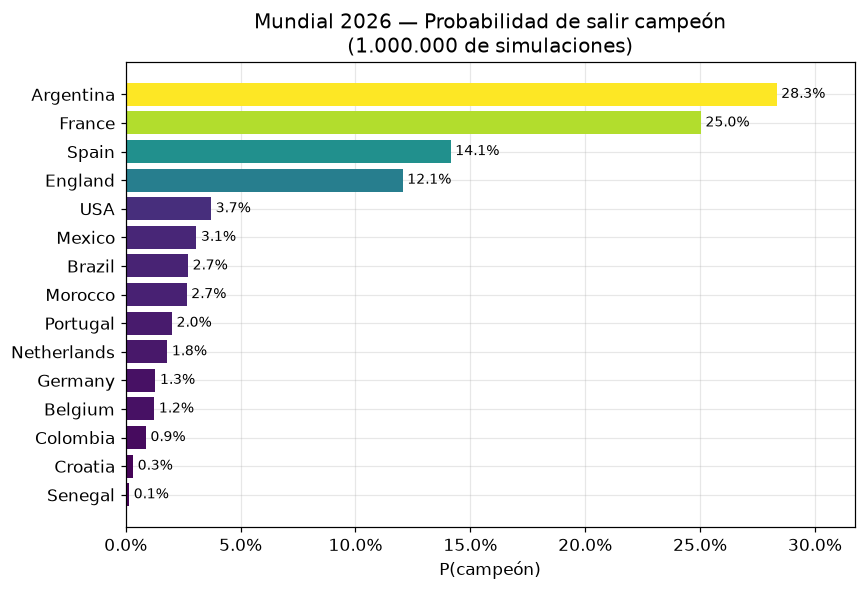

In [6]:
top = df.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 5.5))
bars = ax.barh(top["team"], top["p_champion"], color=plt.cm.viridis(top["p_champion"]/top["p_champion"].max()))
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_xlabel("P(campeón)")
ax.set_title("Mundial 2026 — Probabilidad de salir campeón\n(1.000.000 de simulaciones)")
for b, v in zip(bars, top["p_champion"]):
    ax.text(v + 0.002, b.get_y() + b.get_height()/2, f"{v*100:.1f}%", va="center", fontsize=9)
ax.margins(x=0.12)
plt.tight_layout(); plt.savefig("charts/03_campeon_top15.png", bbox_inches="tight"); plt.show()

### Gráfico 2 — Avance por la grilla: semifinal vs final vs título (top 12)

Muestra que la **llave de eliminatorias completa** entra en el cómputo: cada selección
"se va achicando" a medida que se avanza de semifinal a final a campeón.

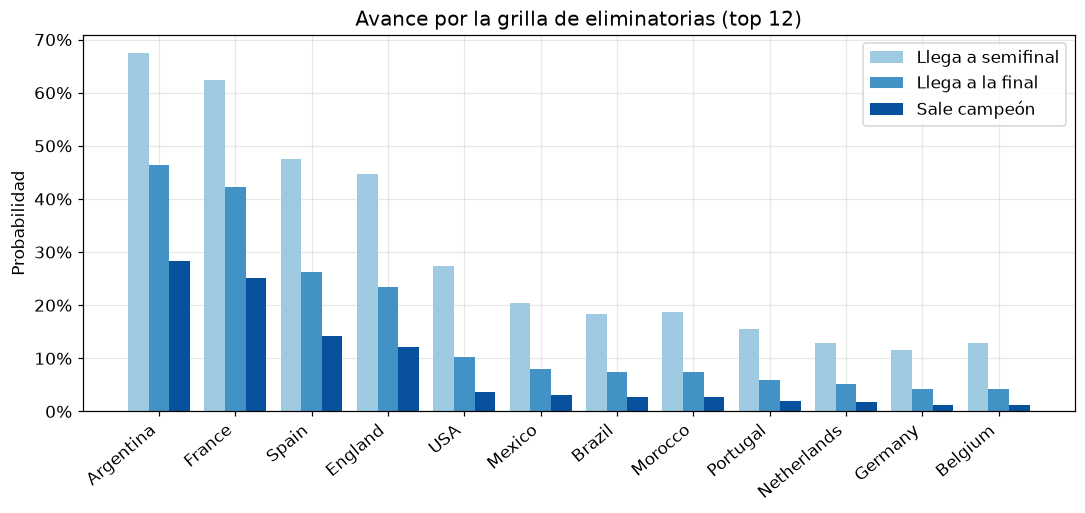

In [7]:
top12 = df.head(12)
import numpy as np
x = np.arange(len(top12)); w = 0.27
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.bar(x - w, top12["p_semi"], w, label="Llega a semifinal", color="#9ecae1")
ax.bar(x,     top12["p_final"], w, label="Llega a la final", color="#4292c6")
ax.bar(x + w, top12["p_champion"], w, label="Sale campeón", color="#08519c")
ax.set_xticks(x); ax.set_xticklabels(top12["team"], rotation=40, ha="right")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_ylabel("Probabilidad"); ax.set_title("Avance por la grilla de eliminatorias (top 12)")
ax.legend()
plt.tight_layout(); plt.savefig("charts/04_avance_grilla.png", bbox_inches="tight"); plt.show()

### Gráfico 3 — ELO vs probabilidad de campeón

Relación monótona entre fuerza (ELO) y chance de título. Las **sedes** (USA, México, Canadá)
quedan por encima de su ELO puro por la ventaja de localía y por su posición en la llave.

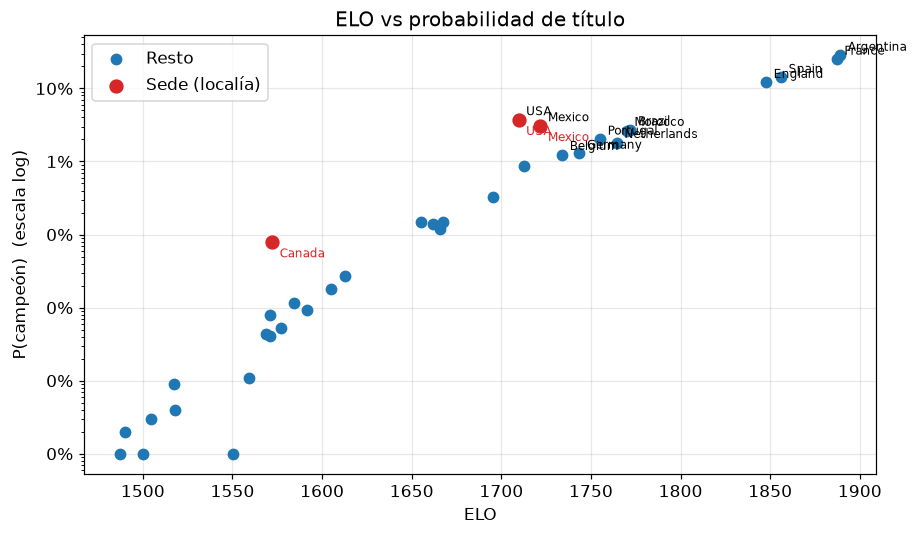

In [8]:
sub = df[df["p_champion"] > 0].copy()
hosts = sub["team"].isin(wcsim.HOSTS)
fig, ax = plt.subplots(figsize=(8.5, 5))
ax.scatter(sub.loc[~hosts, "elo"], sub.loc[~hosts, "p_champion"], s=45, color="#1f77b4", label="Resto")
ax.scatter(sub.loc[hosts, "elo"], sub.loc[hosts, "p_champion"], s=70, color="#d62728", label="Sede (localía)")
ax.set_yscale("log")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_xlabel("ELO"); ax.set_ylabel("P(campeón)  (escala log)")
ax.set_title("ELO vs probabilidad de título")
for _, r in sub.head(12).iterrows():
    ax.annotate(r["team"], (r["elo"], r["p_champion"]),
                textcoords="offset points", xytext=(5, 3), fontsize=8)
for _, r in sub[hosts].iterrows():
    ax.annotate(r["team"], (r["elo"], r["p_champion"]),
                textcoords="offset points", xytext=(5, -10), fontsize=8, color="#d62728")
ax.legend()
plt.tight_layout(); plt.savefig("charts/05_elo_vs_campeon.png", bbox_inches="tight"); plt.show()

## 7. Conclusiones y limitaciones

**Conclusiones (1.000.000 de escenarios, seed 2026):** las cuatro favoritas claras son
**Argentina (~28%)**, **Francia (~25%)**, **España (~14%)** e **Inglaterra (~12%)**, que
concentran cerca del 80% de los títulos. Las sedes (USA, México) y un segundo pelotón
(Brasil, Marruecos, Portugal, Países Bajos) se reparten casi todo el resto. En total más de
30 selecciones ganan en *algún* escenario, pero la cola es muy fina.

**Limitaciones / supuestos:**
- El ELO es un proxy de fuerza; no modela lesiones, suspensiones ni estado de forma.
- Goles modelados como Poisson **independientes** (sin correlación ni efecto del marcador).
- La asignación de terceros usa un matching válido por grupos admitidos, no la tabla FIFA
  exacta de 495 combinaciones (efecto de segundo orden sobre el campeón).
- Algunos ELO de selecciones menores están **estimados** (ver columna `fuente` en `elo.csv`).

A un millón de simulaciones el **ruido de muestreo es despreciable** (las cifras coinciden con
la corrida de 100k hasta la décima): el límite ya no es estadístico sino del **modelo**.